In [ ]:
# Import necessary libraries for graph analysis and visualization
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Initialize lists to store all edges and multiedges
multiedges = [[], []]

# Read the graph from a GEXF file
graph = nx.read_gexf(path="merged_labeled_edges.gexf")

# Iterate over all nodes and their neighbors to collect edge information
for node1 in graph.nodes:
    for node2 in graph.neighbors(node1):
        edge = graph[node1][node2]
        # If there are more than 2 edge attributes, consider it a multiedge
        if len(edge) > 2:
            multiedges[1].append((edge, node1, node2))
        multiedges[0].append((edge, node1, node2))

# Print the number of edges and multiedges, and show examples
print(len(multiedges[0]), len(multiedges[1]))
print(multiedges[0][:5])
print(multiedges[1][:5])

51800 6891
[({'weight0': 0.8, 'id': '0'}, 'odaal', 'thieh'), ({'weight0': 0.9, 'id': '1'}, 'odaal', 'Sharticus123'), ({'weight0': 0.7, 'id': '2'}, 'odaal', 'Brodellsky'), ({'weight0': 0.9, 'id': '3'}, 'odaal', 'Double-decker_trams'), ({'weight0': 0.8, 'id': '4'}, 'thieh', 'Brodellsky')]
[({'weight0': 0.8, 'weight1': 0.6, 'id': '9'}, 'Brodellsky', 'odaal'), ({'weight0': 0.3, 'weight1': 0.3, 'id': '20'}, 'Useful_Document_4120', 'JimboAltAlt'), ({'weight0': 0.6, 'weight1': 0.6, 'weight2': 0.7, 'id': '23'}, 'JimboAltAlt', 'Useful_Document_4120'), ({'weight0': 0.3, 'weight1': 0.4, 'weight2': 0.6, 'weight3': 0.2, 'id': '25'}, 'JimboAltAlt', 'Odd_Wolverine5805'), ({'weight0': 0.3, 'weight1': 0.5, 'id': '27'}, 'JimboAltAlt', 'Charming_Motor_919')]


In [ ]:
# Prepare lists to store deviation statistics for all edges and multiedges
deviations = [[], []]

# For each edge, calculate deviation statistics based on weights
for i in range(2):
    for edge, node1, node2 in multiedges[i]:
        # Extract weight values from edge attributes
        data = np.array([float(val) for (key, val) in edge.items() if "weight" in key])
        mean = np.mean(data)
        deviation = np.abs(data - mean)
        avg_abs_deviation = np.mean(deviation)
        std_deviation = np.std(data)
        # Store standard deviation along with node information
        deviations[i].append(np.array((std_deviation, node1, node2)))

# Convert lists to numpy arrays for easier manipulation
deviations = (np.array(deviations[0]), np.array(deviations[1]))
deviations[0]

array([['0.0', 'odaal', 'thieh'],
       ['0.0', 'odaal', 'Sharticus123'],
       ['0.0', 'odaal', 'Brodellsky'],
       ...,
       ['0.0', '69iamtheliquor69', 'ffnnhhw'],
       ['0.0', 'the_depressed_boerg', 'ffnnhhw'],
       ['0.0', 'GeerJonezzz', 'benzotryptamine']],
      shape=(51800, 3), dtype='<U32')

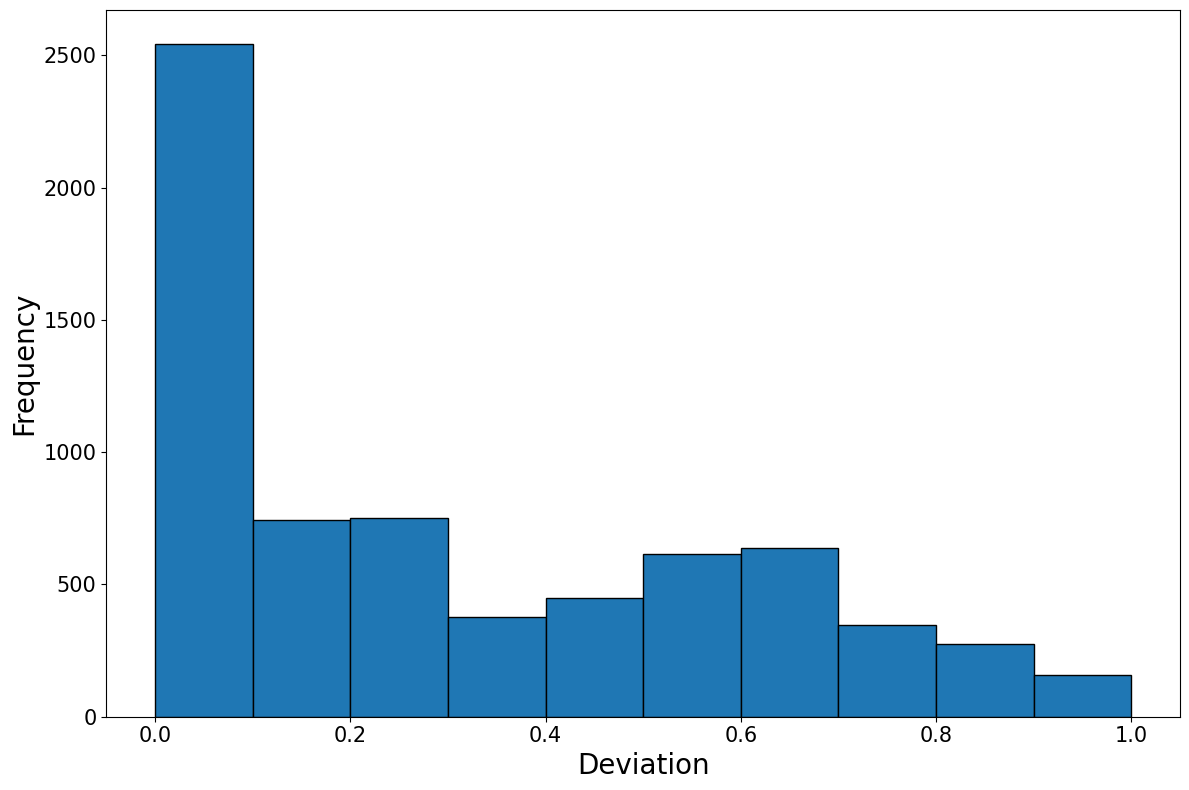

In [ ]:
# Create a histogram to visualize the distribution of deviations for multiedges
fig, axes = plt.subplots(figsize=(12, 8))

# Set axis labels and font sizes
axes.set_ylabel('Frequency', fontsize=20)

axes.set_xlabel('Deviation', fontsize=20)
# Plot histogram of standard deviations for multiedges
axes.hist(deviations[1][:, 0].astype(float), bins=10, edgecolor='black')
axes.tick_params(labelsize=15)
    
plt.tight_layout()
plt.show()

In [ ]:
# Set a threshold for deviation to filter edges
threshold = 0.3

# Find edges with deviation above the threshold
above_threshold = [(str(a), str(b)) for a, b in deviations[0][deviations[0][:, 0].astype(float) > threshold][:, 1:3]]

# Print the number of edges above threshold and show examples
print(len(above_threshold))
above_threshold[:5]

2851


[('Odd_Wolverine5805', 'JimboAltAlt'),
 ('i_tyrant', '427895'),
 ('427895', 'RelaxPrime'),
 ('RelaxPrime', '427895'),
 ('polite_alpha', '427895')]

In [ ]:
# Remove edges above the deviation threshold from the graph
graph.remove_edges_from(above_threshold)

# Remove isolated nodes (nodes with no in or out degree)
isolated_nodes = [n for n in list(graph.nodes) if graph.in_degree(n) == 0 and graph.out_degree(n) == 0]
graph.remove_nodes_from(isolated_nodes)

# For each remaining edge, average the weights and assign a new id
for i, (u, v, data) in enumerate(graph.edges(data=True)):
    weights = []
    for w in data:
        if w.startswith("weight"):
            weights.append(float(data[w]))
    graph[u][v].clear()
    graph[u][v].update({"weight": round(sum(weights) / len(weights), 2), "id": i})

# Save the filtered graph to a new GEXF file
nx.write_gexf(graph, "filtered_graph.gexf")

In [ ]:
# Print the number of nodes and edges in the filtered graph
print(len(graph.nodes))
print(len(graph.edges))

26119
48949
